In [ ]:
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import List, Dict, Optional

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
# In Colab, make sure the file is in /content
!ls -lh /content

total 116K
drwxr-xr-x 1 root root 4.0K Dec 11 14:34 sample_data
-rw-r--r-- 1 root root  91K Jan 11 19:45 water-treatment.data
-rw-r--r-- 1 root root  12K Jan 11 19:45 water-treatment.names
-rw-r--r-- 1 root root  493 Jan 11 20:02 WW4_sensitivity_H3_LR.csv
-rw-r--r-- 1 root root 1.2K Jan 11 20:02 WW4_sensitivity_multiH_LR.csv


In [ ]:
# Path in Colab
DATA_PATH = "/content/water-treatment.data"

# Official column names (from UCI .names documentation)
COLUMN_NAMES = [
    "Q-E", "ZN-E", "PH-E", "DBO-E", "DQO-E", "SS-E", "SSV-E", "SED-E",
    "COND-E", "PH-P", "DBO-P", "SS-P", "SSV-P", "SED-P",
    "COND-P", "PH-D", "DBO-D", "DQO-D", "SS-D", "SSV-D",
    "SED-D", "COND-D", "PH-S", "DBO-S", "DQO-S", "SS-S",
    "SSV-S", "SED-S", "COND-S", "RD-DBO-P", "RD-SS-P",
    "RD-SED-P", "RD-DBO-S", "RD-SS-S", "RD-SED-S"
]

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=COLUMN_NAMES,
    sep=",",
    na_values="?"
)

print("Loaded shape:", df.shape)  # expected (527, 35)
df.head()

Loaded shape: (527, 35)


,,,,Q-E,ZN-E,PH-E,DBO-E,DQO-E,SS-E,SSV-E,SED-E,COND-E,PH-P,...,SS-S,SSV-S,SED-S,COND-S,RD-DBO-P,RD-SS-P,RD-SED-P,RD-DBO-S,RD-SS-S,RD-SED-S
D-1/3/90,44101.0,1.5,7.8,NaN,407.0,166.0,66.3,4.5,2110,7.9,NaN,228,70.2,...,2000.0,NaN,58.8,95.5,NaN,70.0,NaN,79.4,87.3,99.6
D-2/3/90,39024.0,3.0,7.7,NaN,443.0,214.0,69.2,6.5,2660,7.7,NaN,244,75.4,...,2590.0,NaN,60.7,94.8,NaN,80.8,NaN,79.5,92.1,100.0
D-4/3/90,32229.0,5.0,7.6,NaN,528.0,186.0,69.9,3.4,1666,7.7,NaN,220,72.7,...,1888.0,NaN,58.2,95.6,NaN,52.9,NaN,75.8,88.7,98.5
D-5/3/90,35023.0,3.5,7.9,205.0,588.0,192.0,65.6,4.5,2430,7.8,236.0,268,73.1,...,1840.0,33.1,64.2,95.3,87.3,72.3,90.2,82.3,89.6,100.0
D-6/3/90,36924.0,1.5,8.0,242.0,496.0,176.0,64.8,4.0,2110,7.9,NaN,236,57.6,...,2120.0,NaN,62.7,95.6,NaN,71.0,92.1,78.2,87.5,99.5


In [ ]:
# Ensure all columns are numeric (coerce errors to NaN)
num_df = df.copy()
for c in num_df.columns:
    num_df[c] = pd.to_numeric(num_df[c], errors="coerce")

# Drop fully empty columns (just in case)
num_df = num_df.dropna(axis=1, how="all")

# Drop constant columns (just in case)
nunique = num_df.nunique(dropna=True)
num_df = num_df.loc[:, nunique > 1]

print("After cleaning shape:", num_df.shape)
num_df.isna().mean().sort_values(ascending=False).head(10)

After cleaning shape: (527, 35)


,0
SSV-S,0.117647
SED-E,0.075901
RD-DBO-P,0.075901
RD-SED-P,0.068311
RD-SED-S,0.058824
DQO-S,0.053131
SED-P,0.053131
COND-S,0.051233
RD-SS-P,0.049336
DQO-D,0.047438


In [ ]:
X_raw = num_df.to_numpy().astype(float)  # may contain NaNs

# Impute only for event-definition signal
imputer_for_diff = SimpleImputer(strategy="mean")
X_for_diff = imputer_for_diff.fit_transform(X_raw)

print("X_raw shape:", X_raw.shape, "NaN rate:", np.isnan(X_raw).mean())
print("X_for_diff shape:", X_for_diff.shape, "NaN rate:", np.isnan(X_for_diff).mean())

X_raw shape: (527, 35) NaN rate: 0.030902683654106804
X_for_diff shape: (527, 35) NaN rate: 0.0


In [ ]:
def compute_daily_diff_norm(X: np.ndarray) -> np.ndarray:
    """
    X: (T, D) fully numeric, no NaNs recommended.
    Returns diff_norm of length T, with diff_norm[0]=0.
    """
    dX = np.diff(X, axis=0)
    diff_norm = np.linalg.norm(dX, axis=1)
    diff_norm = np.concatenate([[0.0], diff_norm])
    return diff_norm

diff_norm = compute_daily_diff_norm(X_for_diff)

print("diff_norm stats:",
      "min", float(np.min(diff_norm)),
      "median", float(np.median(diff_norm)),
      "max", float(np.max(diff_norm)))

diff_norm stats: min 0.0 median 549.7329669030229 max 4325.292386648561


In [ ]:
def define_event_days_from_percentile(diff_norm: np.ndarray, percentile: float) -> np.ndarray:
    thr = np.percentile(diff_norm, percentile)
    return diff_norm > thr

for p in [80, 85, 90, 95, 97]:
    event_days = define_event_days_from_percentile(diff_norm, p)
    print(f"p{p}: event_days positives = {int(event_days.sum())}")

p80: event_days positives = 106
p85: event_days positives = 79
p90: event_days positives = 53
p95: event_days positives = 27
p97: event_days positives = 16


In [ ]:
def make_horizon_labels(event_days: np.ndarray, H: int) -> np.ndarray:
    """
    event_days: (T,) boolean
    y[t]=1 if any event occurs in [t+1 .. t+H]
    """
    T = len(event_days)
    y = np.zeros(T, dtype=int)
    for t in range(T):
        start = t + 1
        end = min(T, t + 1 + H)
        if start < T and np.any(event_days[start:end]):
            y[t] = 1
    return y

# sanity check
p = 90
H = 3
event_days = define_event_days_from_percentile(diff_norm, p)
y = make_horizon_labels(event_days, H=H)
print("Total positives in y:", int(y.sum()))

Total positives in y: 122


In [ ]:
def window_features(X: np.ndarray, W: int) -> np.ndarray:
    """
    X: (T, D) may include NaNs (we handle them).
    Output F: (T, D*5). For t < W-1, features are NaN.
    Features per variable: last, mean, std, delta(last-first), slope
    """
    T, D = X.shape
    F = np.full((T, D * 5), np.nan, dtype=float)

    t_idx = np.arange(W)
    tt = t_idx - t_idx.mean()
    denom = np.sum(tt**2)

    for t in range(W - 1, T):
        win = X[t - W + 1 : t + 1, :]  # (W, D)

        last = win[-1, :]
        mean = np.nanmean(win, axis=0)
        std  = np.nanstd(win, axis=0)
        delta = win[-1, :] - win[0, :]

        slope = np.full(D, np.nan)
        for d in range(D):
            x = win[:, d]
            mask = ~np.isnan(x)
            if mask.sum() >= 2:
                slope[d] = np.sum(tt[mask] * (x[mask] - np.nanmean(x[mask]))) / denom

        feats = np.concatenate([last, mean, std, delta, slope], axis=0)
        F[t, :] = feats

    return F

W = 14
F = window_features(X_raw, W=W)
print("Feature matrix F shape:", F.shape)

Feature matrix F shape: (527, 175)


In [ ]:
@dataclass
class RollingSplit:
    train_end: int
    val_start: int
    val_end: int

def make_rolling_splits(T: int, initial_train: int, val_size: int, step: int) -> List[RollingSplit]:
    splits = []
    train_end = initial_train
    while True:
        val_start = train_end
        val_end = val_start + val_size
        if val_end > T:
            break
        splits.append(RollingSplit(train_end=train_end, val_start=val_start, val_end=val_end))
        train_end += step
    return splits

T = len(X_raw)

# Good defaults for T=527 (short time series)
splits = make_rolling_splits(
    T=T,
    initial_train=360,  # ensures positives in train more often
    val_size=120,
    step=30
)

print("Number of splits:", len(splits))
splits

Number of splits: 2


[RollingSplit(train_end=360, val_start=360, val_end=480),
 RollingSplit(train_end=390, val_start=390, val_end=510)]

In [ ]:
def split_class_counts(y: np.ndarray, splits: List[RollingSplit]) -> pd.DataFrame:
    rows = []
    for i, sp in enumerate(splits):
        y_train = y[:sp.train_end]
        y_val = y[sp.val_start:sp.val_end]
        rows.append({
            "split": i,
            "train_end": sp.train_end,
            "train_pos": int(y_train.sum()),
            "train_neg": int((y_train == 0).sum()),
            "val_pos": int(y_val.sum()),
            "val_neg": int((y_val == 0).sum()),
        })
    return pd.DataFrame(rows)

p = 90
H = 3
event_days = define_event_days_from_percentile(diff_norm, p)
y = make_horizon_labels(event_days, H=H)

counts_df = split_class_counts(y, splits)
counts_df

,split,train_end,train_pos,train_neg,val_pos,val_neg
0,0,360,92,268,24,96
1,1,390,103,287,19,101


In [ ]:
def make_lr_pipeline() -> Pipeline:
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))
    ])

In [ ]:
def false_alarms_per_30d(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    False alarm: y_pred=1 while y_true=0.
    Scaled to per-30-days.
    """
    fa = np.sum((y_pred == 1) & (y_true == 0))
    days = len(y_true)
    return float(fa * (30.0 / days)) if days > 0 else np.nan

def choose_threshold_max_hit_under_fa(
    y_val: np.ndarray,
    proba_val: np.ndarray,
    event_val: np.ndarray,
    H: int,
    target_fa_30d: float = 1.0,
    grid_size: int = 400
) -> float:
    """
    Choose threshold that:
    1) satisfies FA/30d <= target_fa_30d (computed vs y_val)
    2) maximizes event hit-rate (computed vs event_val)
    If tie, choose the highest threshold (more conservative).
    """
    thresholds = np.linspace(0.0, 1.0, grid_size)

    best_thr = 1.0
    best_hit = -1.0
    best_fa = np.inf

    for thr in thresholds:
        alarms = (proba_val >= thr).astype(int)
        fa30 = false_alarms_per_30d(y_val, alarms)

        # Respect operational constraint
        if fa30 > target_fa_30d:
            continue

        ev = event_based_metrics(event_val, alarms.astype(bool), H=H)
        hit = ev["hit_rate"]

        # Maximize hit-rate; tie-break by lower FA then higher threshold
        if (hit > best_hit) or (hit == best_hit and fa30 < best_fa) or (hit == best_hit and fa30 == best_fa and thr > best_thr):
            best_hit = hit
            best_fa = fa30
            best_thr = thr

    return float(best_thr)

In [ ]:
def event_based_metrics(event_days: np.ndarray, alarm_days: np.ndarray, H: int) -> Dict[str, float]:
    """
    event_days: (T,) boolean: "true event days"
    alarm_days: (T,) boolean: alarm raised on that day
    For an event at day e, count a hit if any alarm in [e-H, e-1].
    Lead time = e - first_alarm_day within that window.
    """
    events = np.where(event_days)[0]
    if len(events) == 0:
        return {"hit_rate": np.nan, "median_lead_time": np.nan, "n_event_days": 0}

    hits = 0
    lead_times = []

    for e in events:
        start = max(0, e - H)
        end = e
        alarm_idxs = np.where(alarm_days[start:end])[0]
        if len(alarm_idxs) > 0:
            hits += 1
            first_alarm_day = start + alarm_idxs[0]
            lead_times.append(e - first_alarm_day)

    hit_rate = hits / len(events)
    median_lt = float(np.median(lead_times)) if len(lead_times) > 0 else np.nan
    return {"hit_rate": float(hit_rate), "median_lead_time": median_lt, "n_event_days": int(len(events))}

In [ ]:
def run_rolling_origin_lr(
    F: np.ndarray,
    y: np.ndarray,
    event_days: np.ndarray,
    splits: List[RollingSplit],
    H: int,
    target_fa_30d: float = 1.0
) -> pd.DataFrame:
    rows = []

    for i, sp in enumerate(splits):
        X_train = F[:sp.train_end]
        y_train = y[:sp.train_end]

        X_val = F[sp.val_start:sp.val_end]
        y_val = y[sp.val_start:sp.val_end]
        event_val = event_days[sp.val_start:sp.val_end]

        # Must have 2 classes in train to fit LR
        if len(np.unique(y_train)) < 2:
            rows.append({
                "split": i,
                "status": "SKIP_train_one_class",
                "train_end": sp.train_end,
                "val_start": sp.val_start,
                "val_end": sp.val_end,
                "train_pos": int(y_train.sum()),
                "val_pos": int(y_val.sum()),
                "roc_auc": np.nan,
                "avg_precision": np.nan,
                "threshold": np.nan,
                "fa_per_30d": np.nan,
                "hit_rate": np.nan,
                "median_lead_time": np.nan,
                "n_event_days": int(event_val.sum()),
            })
            continue

        model = make_lr_pipeline()
        model.fit(X_train, y_train)
        proba_val = model.predict_proba(X_val)[:, 1]

        # Classic metrics only if val has 2 classes
        roc = roc_auc_score(y_val, proba_val) if len(np.unique(y_val)) > 1 else np.nan
        ap  = average_precision_score(y_val, proba_val) if len(np.unique(y_val)) > 1 else np.nan

        # Threshold selection (operational constraint)
        if np.all(y_val == 1):
            thr = np.nan
            alarms = np.zeros_like(y_val)
            fa30 = np.nan
        else:
            thr = choose_threshold_max_hit_under_fa(
                y_val=y_val,
                proba_val=proba_val,
                event_val=event_val,
                H=H,
                target_fa_30d=target_fa_30d
            )
            alarms = (proba_val >= thr).astype(int)
            fa30 = false_alarms_per_30d(y_val, alarms)

        ev = event_based_metrics(event_val, alarms.astype(bool), H=H)

        rows.append({
            "split": i,
            "status": "OK",
            "train_end": sp.train_end,
            "val_start": sp.val_start,
            "val_end": sp.val_end,
            "train_pos": int(y_train.sum()),
            "val_pos": int(y_val.sum()),
            "roc_auc": float(roc) if roc == roc else np.nan,
            "avg_precision": float(ap) if ap == ap else np.nan,
            "threshold": float(thr) if thr == thr else np.nan,
            "fa_per_30d": float(fa30) if fa30 == fa30 else np.nan,
            **ev,
        })

    return pd.DataFrame(rows)

# Quick test run
p = 90
H = 3
event_days = define_event_days_from_percentile(diff_norm, p)
y = make_horizon_labels(event_days, H=H)

df_roll = run_rolling_origin_lr(F, y, event_days, splits, H=H, target_fa_30d=1.0)
df_roll

,split,status,train_end,val_start,val_end,train_pos,val_pos,roc_auc,avg_precision,threshold,fa_per_30d,hit_rate,median_lead_time,n_event_days
0,0,OK,360,360,480,92,24,0.344184,0.152962,1.0,0.0,0.0,NaN,13
1,1,OK,390,390,510,103,19,0.276186,0.109481,1.0,0.0,0.0,NaN,9


In [ ]:
def summarize_rolling(df_roll: pd.DataFrame) -> Dict[str, float]:
    ok = df_roll[df_roll["status"] == "OK"].copy()
    return {
        "n_splits_total": int(len(df_roll)),
        "n_splits_ok": int(len(ok)),
        "roc_auc_mean": float(np.nanmean(ok["roc_auc"])) if len(ok) else np.nan,
        "ap_mean": float(np.nanmean(ok["avg_precision"])) if len(ok) else np.nan,
        "fa30_mean": float(np.nanmean(ok["fa_per_30d"])) if len(ok) else np.nan,
        "hit_rate_mean": float(np.nanmean(ok["hit_rate"])) if len(ok) else np.nan,
        "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,
        "n_event_days_total_val": int(np.nansum(ok["n_event_days"])) if len(ok) else 0
    }

summ = summarize_rolling(df_roll)
summ

/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,


{'n_splits_total': 2,
 'n_splits_ok': 2,
 'roc_auc_mean': 0.31018477053297433,
 'ap_mean': 0.13122149699394997,
 'fa30_mean': 0.0,
 'hit_rate_mean': 0.0,
 'lead_time_median_of_medians': nan,
 'n_event_days_total_val': 22}

In [ ]:
PERCENTILES = [80, 85, 90, 95, 97]
H = 3
TARGET_FA30 = 1.0

rows = []
for p in PERCENTILES:
    event_days = define_event_days_from_percentile(diff_norm, p)
    y = make_horizon_labels(event_days, H=H)

    df_roll = run_rolling_origin_lr(F, y, event_days, splits, H=H, target_fa_30d=TARGET_FA30)
    summ = summarize_rolling(df_roll)

    rows.append({
        "percentile": p,
        "event_days_total": int(event_days.sum()),
        "y_total_positives": int(y.sum()),
        **summ
    })

sens_df = pd.DataFrame(rows).sort_values("percentile")
sens_df

/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,
/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,


,percentile,event_days_total,y_total_positives,n_splits_total,n_splits_ok,roc_auc_mean,ap_mean,fa30_mean,hit_rate_mean,lead_time_median_of_medians,n_event_days_total_val
0,80,106,210,2,2,0.524679,0.357940,0.375,0.113636,2.0,38
1,85,79,165,2,2,0.424181,0.228783,0.375,0.125000,1.5,27
2,90,53,122,2,2,0.310185,0.131221,0.000,0.000000,NaN,22
3,95,27,73,2,2,0.211800,0.073765,0.250,0.083333,1.0,10
4,97,16,44,2,2,0.456146,0.054673,0.000,0.000000,NaN,6


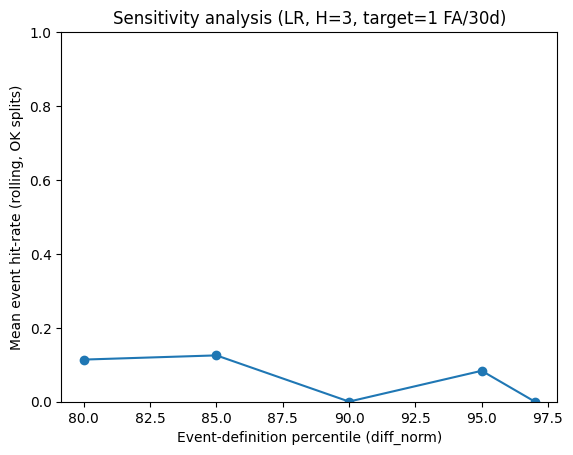

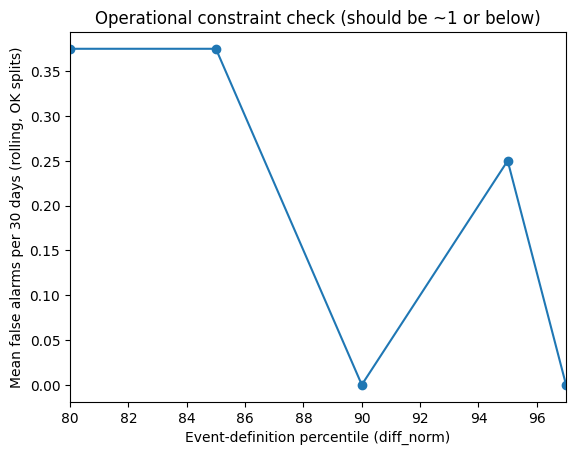

In [ ]:
plt.figure()
plt.plot(sens_df["percentile"], sens_df["hit_rate_mean"], marker="o")
plt.xlabel("Event-definition percentile (diff_norm)")
plt.ylabel("Mean event hit-rate (rolling, OK splits)")
plt.title("Sensitivity analysis (LR, H=3, target=1 FA/30d)")
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(sens_df["percentile"], sens_df["fa30_mean"], marker="o")
plt.xlabel("Event-definition percentile (diff_norm)")
plt.ylabel("Mean false alarms per 30 days (rolling, OK splits)")
plt.title("Operational constraint check (should be ~1 or below)")
plt.xlim(min(PERCENTILES), max(PERCENTILES))
plt.show()

In [ ]:
PERCENTILES = [80, 85, 90, 95, 97]
Hs = [1, 3, 7]
TARGET_FA30 = 1.0

rows = []
for H in Hs:
    for p in PERCENTILES:
        event_days = define_event_days_from_percentile(diff_norm, p)
        y = make_horizon_labels(event_days, H=H)

        df_roll = run_rolling_origin_lr(F, y, event_days, splits, H=H, target_fa_30d=TARGET_FA30)
        summ = summarize_rolling(df_roll)

        rows.append({
            "H": H,
            "percentile": p,
            "event_days_total": int(event_days.sum()),
            "y_total_positives": int(y.sum()),
            **summ
        })

multi_sens_df = pd.DataFrame(rows).sort_values(["H", "percentile"])
multi_sens_df

/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,
/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,
/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,
/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,
/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medians": float(np.nanmedian(ok["median_lead_time"])) if len(ok) else np.nan,
/tmp/ipython-input-776824233.py:10: RuntimeWarning: All-NaN slice encountered
  "lead_time_median_of_medi

,H,percentile,event_days_total,y_total_positives,n_splits_total,n_splits_ok,roc_auc_mean,ap_mean,fa30_mean,hit_rate_mean,lead_time_median_of_medians,n_event_days_total_val
0,1,80,106,106,2,2,0.518282,0.197191,0.375,0.022727,1.0,38
1,1,85,79,79,2,2,0.566151,0.186666,0.875,0.139205,1.0,27
2,1,90,53,53,2,2,0.353073,0.076053,0.000,0.000000,NaN,22
3,1,95,27,27,2,2,0.512301,0.056320,0.000,0.000000,NaN,10
4,1,97,16,16,2,2,0.428258,0.031995,0.000,0.000000,NaN,6
5,3,80,106,210,2,2,0.524679,0.357940,0.375,0.113636,2.0,38
6,3,85,79,165,2,2,0.424181,0.228783,0.375,0.125000,1.5,27
7,3,90,53,122,2,2,0.310185,0.131221,0.000,0.000000,NaN,22
8,3,95,27,73,2,2,0.211800,0.073765,0.250,0.083333,1.0,10
9,3,97,16,44,2,2,0.456146,0.054673,0.000,0.000000,NaN,6


In [ ]:
sens_df.to_csv("WW4_sensitivity_H3_LR.csv", index=False)
multi_sens_df.to_csv("WW4_sensitivity_multiH_LR.csv", index=False)

print("Saved: WW4_sensitivity_H3_LR.csv")
print("Saved: WW4_sensitivity_multiH_LR.csv")

Saved: WW4_sensitivity_H3_LR.csv
Saved: WW4_sensitivity_multiH_LR.csv


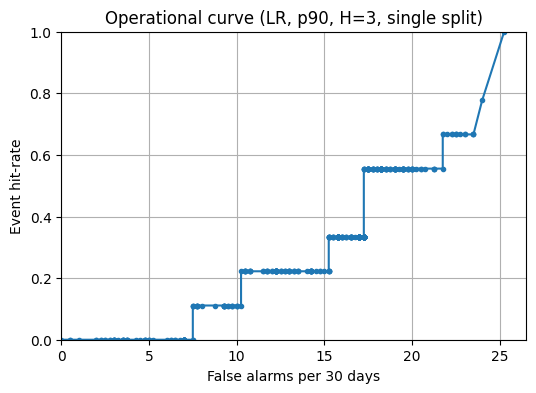

,threshold,fa_per_30d,hit_rate,median_lead_time
0,0.000000,25.25,1.000000,3.0
1,0.002506,24.00,0.777778,3.0
2,0.005013,23.50,0.666667,3.0
3,0.007519,23.50,0.666667,3.0
4,0.010025,23.50,0.666667,3.0


In [ ]:
# =========================
# Operational curve for p90, H=3, single split
# =========================

# Fixed configuration
p = 90
H = 3

# Define events and labels
event_days = define_event_days_from_percentile(diff_norm, p)
y = make_horizon_labels(event_days, H=H)

# Use the last rolling split for visualization
sp = splits[-1]

X_train = F[:sp.train_end]
y_train = y[:sp.train_end]

X_val = F[sp.val_start:sp.val_end]
y_val = y[sp.val_start:sp.val_end]
event_val = event_days[sp.val_start:sp.val_end]

# Train model
model = make_lr_pipeline()
model.fit(X_train, y_train)

# Predict probabilities
proba_val = model.predict_proba(X_val)[:, 1]

# Sweep thresholds
thresholds = np.linspace(0.0, 1.0, 400)

rows = []
for thr in thresholds:
    alarms = (proba_val >= thr).astype(int)

    fa30 = false_alarms_per_30d(y_val, alarms)
    ev = event_based_metrics(event_val, alarms.astype(bool), H=H)

    rows.append({
        "threshold": thr,
        "fa_per_30d": fa30,
        "hit_rate": ev["hit_rate"],
        "median_lead_time": ev["median_lead_time"]
    })

curve_df = pd.DataFrame(rows)

# Plot operational curve
plt.figure(figsize=(6, 4))
plt.plot(curve_df["fa_per_30d"], curve_df["hit_rate"], marker=".")
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate")
plt.title("Operational curve (LR, p90, H=3, single split)")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

curve_df.head()

In [ ]:
# =========================
# Split-level operational curve utilities
# =========================

def operational_curve_for_split(
    F: np.ndarray,
    y: np.ndarray,
    event_days: np.ndarray,
    sp: RollingSplit,
    H: int,
    thresholds: np.ndarray
) -> pd.DataFrame:
    """
    Build operational curve for a single rolling split:
    - Train on [0:train_end)
    - Evaluate on [val_start:val_end)
    - Sweep thresholds -> compute FA/30d (vs y_val) and hit-rate (vs event_val)
    Returns a DataFrame with columns: threshold, fa_per_30d, hit_rate, median_lead_time
    """
    X_train = F[:sp.train_end]
    y_train = y[:sp.train_end]

    X_val = F[sp.val_start:sp.val_end]
    y_val = y[sp.val_start:sp.val_end]
    event_val = event_days[sp.val_start:sp.val_end]

    # Skip if train has only one class
    if len(np.unique(y_train)) < 2:
        return pd.DataFrame()

    model = make_lr_pipeline()
    model.fit(X_train, y_train)
    proba_val = model.predict_proba(X_val)[:, 1]

    rows = []
    for thr in thresholds:
        alarms = (proba_val >= thr).astype(int)
        fa30 = false_alarms_per_30d(y_val, alarms)
        ev = event_based_metrics(event_val, alarms.astype(bool), H=H)

        rows.append({
            "threshold": float(thr),
            "fa_per_30d": float(fa30),
            "hit_rate": float(ev["hit_rate"]),
            "median_lead_time": float(ev["median_lead_time"]) if ev["median_lead_time"] == ev["median_lead_time"] else np.nan
        })

    dfc = pd.DataFrame(rows)

    # Remove NaNs/infs and sort by FA for interpolation stability
    dfc = dfc.replace([np.inf, -np.inf], np.nan).dropna(subset=["fa_per_30d", "hit_rate"])
    dfc = dfc.sort_values("fa_per_30d").reset_index(drop=True)

    # Keep only unique FA values (avoid interpolation issues with duplicates)
    dfc = dfc.groupby("fa_per_30d", as_index=False).agg({
        "hit_rate": "max",  # best achievable hit-rate at that FA level
        "threshold": "min", # not used, but kept
        "median_lead_time": "median"
    }).sort_values("fa_per_30d").reset_index(drop=True)

    return dfc

In [ ]:
# =========================
# Averaged operational curve over rolling splits
# =========================

def averaged_operational_curve(
    F: np.ndarray,
    diff_norm: np.ndarray,
    splits: List[RollingSplit],
    percentile: int,
    H: int,
    thresholds: np.ndarray = None,
    fa_grid: np.ndarray = None
) -> Dict[str, object]:
    """
    Compute per-split operational curves and average them on a common FA grid.
    Returns dict with:
      - curves: list of per-split DataFrames
      - fa_grid: common x-axis
      - hit_rate_mean, hit_rate_p25, hit_rate_p75: aggregated stats
    """
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 400)

    # Define event days and horizon labels
    event_days = define_event_days_from_percentile(diff_norm, percentile)
    y = make_horizon_labels(event_days, H=H)

    # Build per-split curves
    curves = []
    max_fa_seen = 0.0

    for sp in splits:
        dfc = operational_curve_for_split(F, y, event_days, sp, H=H, thresholds=thresholds)
        if len(dfc) == 0:
            continue
        curves.append(dfc)
        max_fa_seen = max(max_fa_seen, float(dfc["fa_per_30d"].max()))

    if len(curves) == 0:
        return {"curves": [], "fa_grid": None, "hit_rate_mean": None}

    # Define FA grid if not provided
    if fa_grid is None:
        # Use a dense grid up to the max FA observed across splits
        fa_grid = np.linspace(0.0, max(1.0, max_fa_seen), 200)

    # Interpolate each curve onto the common FA grid
    hit_matrix = []

    for dfc in curves:
        x = dfc["fa_per_30d"].to_numpy()
        yhit = dfc["hit_rate"].to_numpy()

        # If a curve has only one point, treat as constant
        if len(x) == 1:
            interp = np.full_like(fa_grid, yhit[0], dtype=float)
        else:
            # np.interp requires increasing x (we ensured sorting)
            # For values beyond range, it uses left/right endpoints -> that's fine
            interp = np.interp(fa_grid, x, yhit)

        hit_matrix.append(interp)

    hit_matrix = np.vstack(hit_matrix)  # (n_curves, len(fa_grid))

    hit_rate_mean = np.nanmean(hit_matrix, axis=0)
    hit_rate_p25 = np.nanpercentile(hit_matrix, 25, axis=0)
    hit_rate_p75 = np.nanpercentile(hit_matrix, 75, axis=0)

    return {
        "curves": curves,
        "fa_grid": fa_grid,
        "hit_rate_mean": hit_rate_mean,
        "hit_rate_p25": hit_rate_p25,
        "hit_rate_p75": hit_rate_p75,
        "n_splits_used": len(curves),
        "percentile": percentile,
        "H": H
    }

Splits used: 2 out of 2


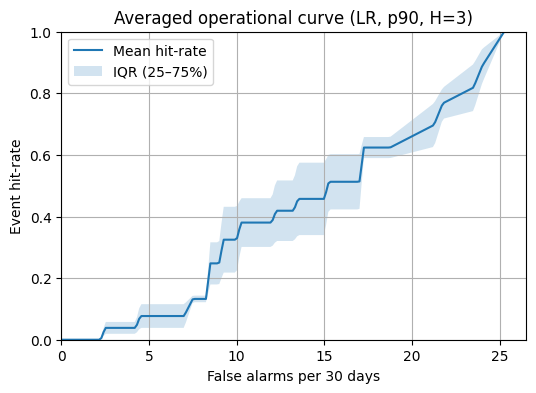

In [ ]:
# =========================
# Run averaged curve for p90, H=3
# =========================

percentile = 90
H = 3

out = averaged_operational_curve(
    F=F,
    diff_norm=diff_norm,
    splits=splits,
    percentile=percentile,
    H=H,
    thresholds=np.linspace(0.0, 1.0, 400),
    fa_grid=None
)

print("Splits used:", out["n_splits_used"], "out of", len(splits))

fa_grid = out["fa_grid"]
hit_mean = out["hit_rate_mean"]
hit_p25 = out["hit_rate_p25"]
hit_p75 = out["hit_rate_p75"]

plt.figure(figsize=(6,4))
plt.plot(fa_grid, hit_mean, label="Mean hit-rate")
plt.fill_between(fa_grid, hit_p25, hit_p75, alpha=0.2, label="IQR (25–75%)")
plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate")
plt.title(f"Averaged operational curve (LR, p{percentile}, H={H})")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

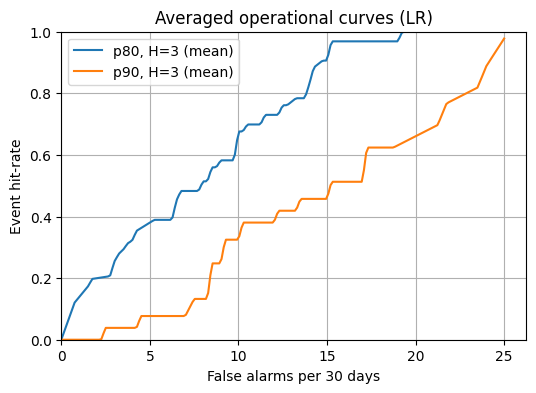

In [ ]:
# =========================
# Compare p80 vs p90 averaged curves
# =========================

configs = [(80, 3), (90, 3)]
plt.figure(figsize=(6,4))

for percentile, H in configs:
    out = averaged_operational_curve(
        F=F, diff_norm=diff_norm, splits=splits,
        percentile=percentile, H=H,
        thresholds=np.linspace(0.0, 1.0, 400),
        fa_grid=np.linspace(0.0, 25.0, 200)  # fixed grid for fair comparison
    )
    plt.plot(out["fa_grid"], out["hit_rate_mean"], label=f"p{percentile}, H={H} (mean)")

plt.xlabel("False alarms per 30 days")
plt.ylabel("Event hit-rate")
plt.title("Averaged operational curves (LR)")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# =========================
# Export numerical values of the averaged operational curve
# =========================

curve_avg_df = pd.DataFrame({
    "fa_per_30d": fa_grid,
    "hit_rate_mean": hit_mean,
    "hit_rate_p25": hit_p25,
    "hit_rate_p75": hit_p75
})

# Define FA levels of interest (edit if you want more / fewer)
fa_levels = [0, 0.5, 1, 2, 5, 7.5, 10, 15, 20, 25]

# For each target FA, find the closest value in the grid
rows = []
for fa in fa_levels:
    idx = np.argmin(np.abs(curve_avg_df["fa_per_30d"] - fa))
    rows.append(curve_avg_df.iloc[idx])

summary_df = pd.DataFrame(rows).reset_index(drop=True)

summary_df


,fa_per_30d,hit_rate_mean,hit_rate_p25,hit_rate_p75
0,0.000000,0.000000,0.000000,0.000000
1,0.507538,0.000000,0.000000,0.000000
2,1.015075,0.000000,0.000000,0.000000
3,2.030151,0.000000,0.000000,0.000000
4,4.948492,0.076923,0.038462,0.115385
5,7.486181,0.130943,0.119492,0.142395
6,10.023869,0.330091,0.225905,0.434276
7,14.972362,0.457265,0.339744,0.574786
8,20.047739,0.661961,0.608758,0.715163
9,24.996231,0.977443,0.966164,0.988721
